# Reservoir Plot

Author: Ilan Valencius

In [1]:
import xarray as xr
import rioxarray
from rioxarray.merge import merge_arrays
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import glob
import numpy as np

files = [
    '20240927T160939_20240927T161609_T16RFV',
    '20240927T160939_20240927T161609_T16RGV',
]

# Open each tile and select band 1
datasets = [rioxarray.open_rasterio('ssc/'+f+'_ssc_cluster2.tif', chunks=True).sel(band=1).rename('ssc') for f in files]

# Mosaic tiles into a single array (handles different domains, fills gaps with nodata)
ssc = merge_arrays(datasets)

# Reproject to WGS84 (EPSG:4326) — converts x/y to lat/lon
ssc = ssc.rio.reproject("EPSG:4326")

# Rename spatial dims for clarity
ssc = ssc.rename({'x': 'lon', 'y': 'lat'})

# Apply nan filtering
fill_value = ssc.attrs.get('_FillValue', np.nan)
ssc = ssc.where(ssc != fill_value)

# Filter to study region
ssc = ssc.sel(lon=slice(-85, -84.7), lat=slice(30.85, 30.7))
ssc

<xarray.DataArray 'ssc' (lat: 757, lon: 1515)> Size: 5MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Coordinates:
  * lon          (lon) float64 12kB -85.0 -85.0 -85.0 ... -84.7 -84.7 -84.7
  * lat          (lat) float64 6kB 30.85 30.85 30.85 30.85 ... 30.7 30.7 30.7
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  1166.3699951172
    STATISTICS_MEAN:     -9999
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   -9999
    scale_factor:        1.0
    add_offset:          0.0
    _FillValue:          -3.4e+38

## Prep basemap

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.5590909].


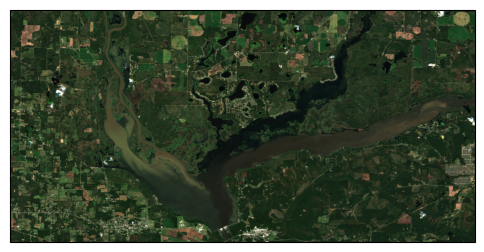

In [2]:
datasets = [rioxarray.open_rasterio('basemaps/'+f+'.tif', chunks=True).rename('basemap') for f in files]
# Mosaic tiles into a single array (handles different domains, fills gaps with nodata)
basemap = merge_arrays(datasets)
basemap = basemap.rio.reproject("EPSG:4326")
basemap = basemap.rename({'x': 'lon', 'y': 'lat'})
basemap = basemap.sel(lon=slice(-85, -84.7), lat=slice(30.85, 30.7))

# Convert to (lat, lon, 3)
# RGB is B4, B3, B2
rgb = basemap.reindex(band=[3, 2, 1]).transpose('lat', 'lon', 'band').values

# Normalize, max value in GEE is 2200
rgb = rgb / 2200

fig, ax = plt.subplots(
    figsize=(6, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

ax.imshow(rgb, origin='upper', extent=[
    basemap.lon.min(), basemap.lon.max(),
    basemap.lat.min(), basemap.lat.max()
])
plt.show()

## Plot

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.5590909].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..3.5590909].


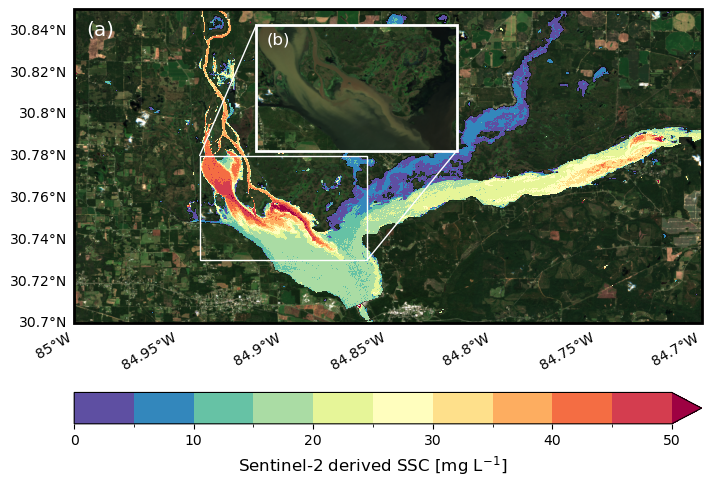

In [8]:
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Overarching parameters for SSC plots
cmap = sns.color_palette('Spectral_r', as_cmap=True)

def add_latlon(ax):
    proj=ccrs.PlateCarree()
    gl = ax.gridlines(
        crs=proj, draw_labels=True, which='both',
        linewidth=1, color='k', alpha=1, linestyle='--'
    )
    gl.right_labels = None
    gl.top_labels = None
    gl.xlines = None
    gl.ylines = None
    # Increase the ticksize
    gl.xlabel_style = {'size': 10, 'color': 'k', 'rotation':30, 'ha':'right'}
    gl.ylabel_style = {'size': 10, 'color': 'k', 'weight': 'normal'}

def big_ax(ax, lw=2):
    for spine in ax.spines.values():
        spine.set_linewidth(lw)

fig, ax = plt.subplots(
    figsize=(7, 5),
    layout='compressed',
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# Main plot
ax.imshow(
    rgb, 
    origin='upper', 
    extent=[
        basemap.lon.min(), basemap.lon.max(),
        basemap.lat.min(), basemap.lat.max()
    ],
    transform=ccrs.PlateCarree()
)
im = ssc.plot(
    ax=ax,
    levels=np.linspace(0, 50, 10+1),
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    add_colorbar=False,
)
ax.text(
    0.02, 0.92, '(a)', size='x-large',
    color='white',
    transform=ax.transAxes
)

# Inset plot
# inset Axes....
x1, x2, y1, y2 = -84.94, -84.86, 30.73, 30.78  # subregion of the original image
# x1, x2, y1, y2 = -84.92, -84.89, 30.74, 30.76  # subregion of the original image
axins = ax.inset_axes(
    [0.25, 0.55, 0.4, 0.4],
    xlim=(x1, x2), ylim=(y1, y2),
    xticklabels=[], yticklabels=[],
    projection=ccrs.PlateCarree()
)
axins.imshow(
    rgb, 
    origin='upper', 
    extent=[
        basemap.lon.min(), basemap.lon.max(),
        basemap.lat.min(), basemap.lat.max()
    ],
    transform=ccrs.PlateCarree()
)
axins.text(
    0.05, 0.85, '(b)', size='large',
    color='white',
    transform=axins.transAxes
)

# im = ssc.plot(
#     ax=axins,
#     vmax=50,
#     cmap=cmap,
#     transform=ccrs.PlateCarree(),
#     add_colorbar=False,
# )
for spine in axins.spines.values():
    spine.set_edgecolor('white')
big_ax(axins)
axins.set_title('')
ax.indicate_inset_zoom(axins, edgecolor='white', lw=1, alpha=1)


# Cosmetics
big_ax(ax)
add_latlon(ax)

cbar = fig.colorbar(im, ax=ax, orientation='horizontal')
cbar.set_label(r'Sentinel-2 derived SSC [mg L$^{-1}$]', fontsize='large')
# ax.set_title('(a) Lake Seminole, GA after Hurricane Helene (2024-09-27)', fontsize='x-large')
ax.set_title('')
plt.savefig('seminole-helene.png', dpi=300)
plt.show()